[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mbanuelos/grad_math_modeling/blob/main/Lectures/Module0_TimeSeries/03_AutocorrelationAndDiagnostics.ipynb#copy=true)

# Autocorrelation and Reusable Time-Series Diagnostics

## Learning objectives

By the end of this lesson, you should be able to:

- Interpret ACF and PACF plots and their confidence bands.
- Recognize seasonal dependence at meaningful lags.
- Combine visual, ADF, and correlation evidence in a diagnostic workflow.

## Setup for this lesson

This cell recreates the data and completed prerequisites from earlier lessons, so this notebook can be run in a fresh kernel.

In [ ]:
# Shared setup from the preceding lesson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']

df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff'] = df['Log_Passengers'].diff()


***
## Part 5 — Autocorrelation Function (ACF)

### What is autocorrelation?

**Autocorrelation** measures how strongly a time series is correlated with a **lagged version
of itself**.

- **Lag 1** autocorrelation: correlation between `x[t]` and `x[t-1]`
- **Lag 12** autocorrelation: correlation between `x[t]` and `x[t-12]`

A high autocorrelation at lag 12 in monthly data means "what happened a year ago is a strong
predictor of today" — a signature of **annual seasonality**.

The **ACF plot** (correlogram) shows autocorrelation for many lags at once. The **blue shaded
band** is the 95% confidence interval — spikes *outside* this band are statistically significant.

The **PACF** (Partial ACF) shows the *direct* correlation at each lag after removing effects
mediated through shorter lags.

### 5.1 ACF of the original series

This cell is complete — run it and observe the shape of the ACF.

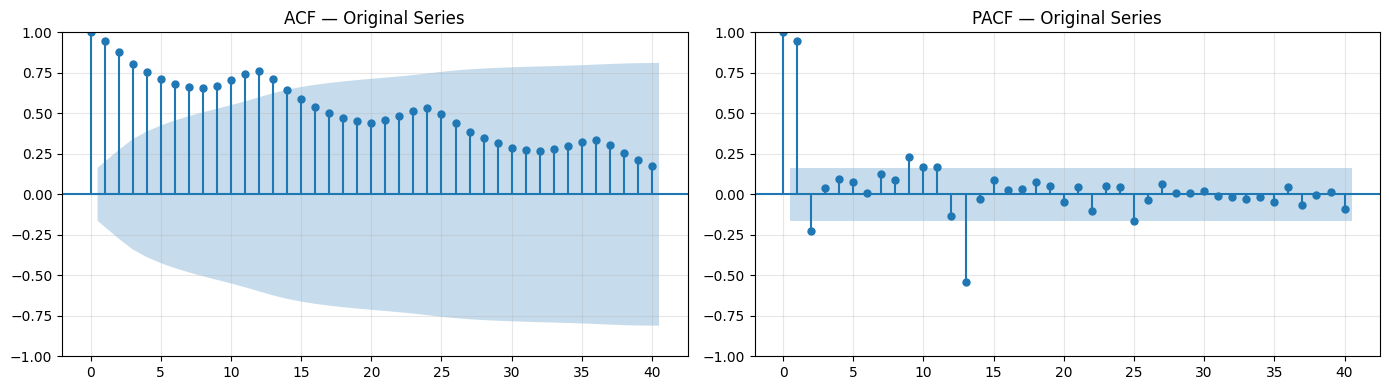

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf( df['Passengers'], lags=40, ax=axes[0])
axes[0].set_title('ACF — Original Series')

plot_pacf(df['Passengers'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Original Series')

plt.tight_layout()
plt.show()

### 5.2 ACF of the log-differenced (stationary) series

**Your turn!** Fill in the blanks to plot the ACF and PACF for `df['Log_Diff']`.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# FILL IN: plot ACF for df['Log_Diff'] with 40 lags
plot_acf(df[???], lags=???, ax=axes[0])
axes[0].set_title('ACF — Log-Differenced Series')

# FILL IN: plot PACF for df['Log_Diff'] with 40 lags
plot_pacf(df[???], lags=???, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Log-Differenced Series')

plt.tight_layout()
plt.show()

### ✏️ Written Response 5

Compare the two sets of ACF plots and answer:

1. In the **original** ACF, autocorrelation decays very slowly and stays positive for many
   lags. What does this pattern suggest about the series?
2. In the **log-differenced** ACF, which lags have significant spikes? What does a spike at
   lag 12 tell you?
3. What is the difference between the ACF and the PACF? Why might you want both?

> **YOUR ANSWER:**

***
## Part 6 — Putting It All Together

The function below packages all three diagnostics into one reusable tool. You will use
this pattern throughout the week whenever you encounter a new time series.

Run it on both versions of the Air Passengers series and compare the panels.

In [ ]:
def ts_diagnostics(series, label='Series', lags=40, rolling_window=12):
    """
    Full diagnostic panel for a time series:
      1. Raw plot with rolling mean and std
      2. ADF test result shown in axis label
      3. ACF and PACF plots
    """
    series = series.dropna()
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    roll_mean = series.rolling(rolling_window).mean()
    roll_std = series.rolling(rolling_window).std()

    # plots
    axes[0].plot(series, label='Series')
    axes[0].plot(roll_mean, label=f'{rolling_window}-period Mean', color='crimson')
    axes[0].plot(roll_std, label=f'{rolling_window}-period Std', color='orange')
    axes[0].set_title(f'{label}: Raw + Rolling Stats')

    adf_result = adfuller(series)
    p = adf_result[1]
    status = 'STATIONARY' if p <0.05 else 'NON-STATIONARY'
    axes[0].set_xlabel(f'ADF p-value = {p:.4f} -> {status}')

    # plot 2
    plot_acf(series, lags=lags, ax=axes[1])
    axes[1].set_title(f'{label}: ACF')

    # plot 3
    plot_acf(series, lags=lags, ax=axes[2])
    axes[2].set_title(f'{label}: PACF')

    plt.tight_layout()
    plt.show()

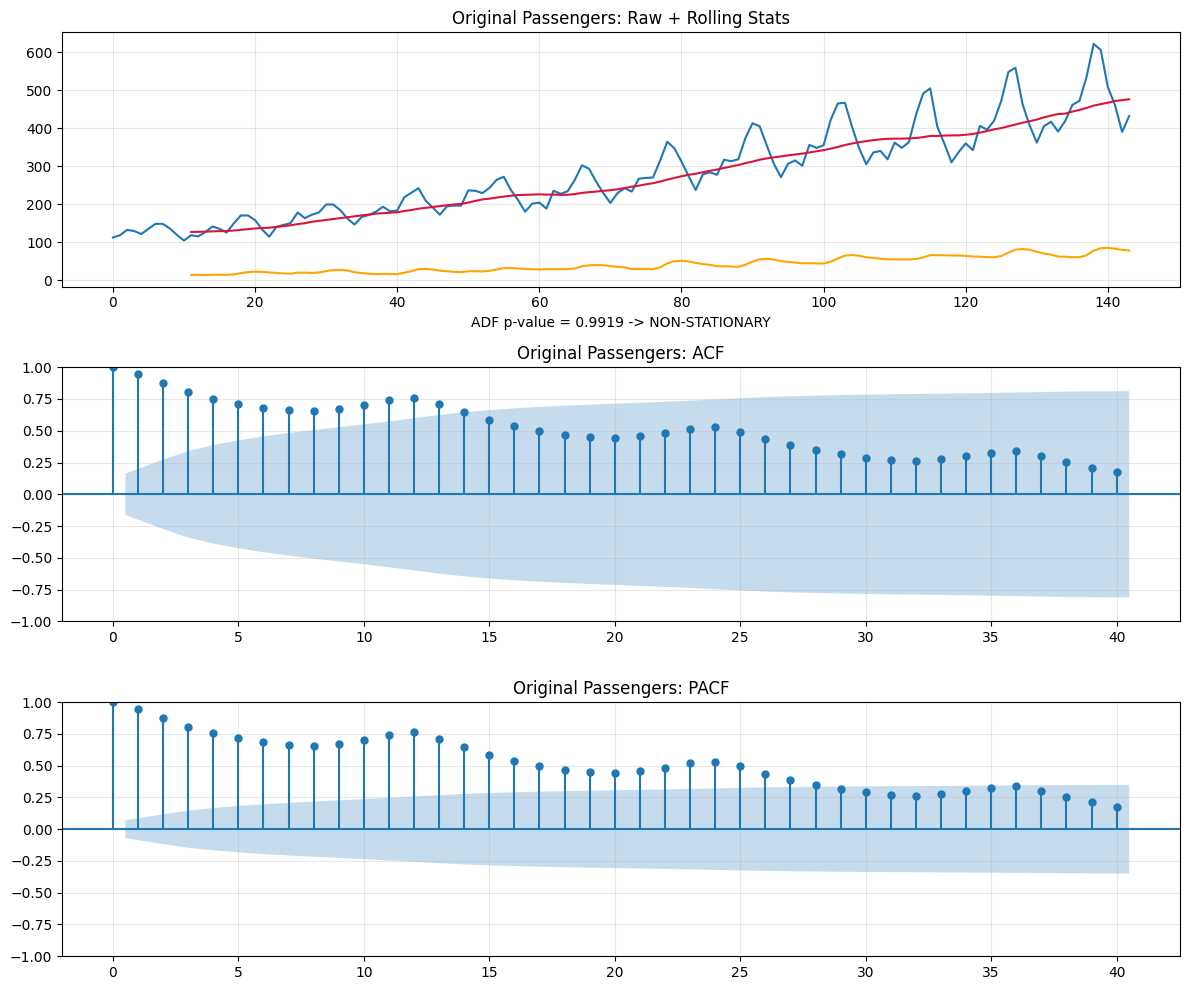

In [14]:
ts_diagnostics(df['Passengers'], label='Original Passengers')

### ✏️ Final Written Reflection

Write a **4–6 sentence diagnostic summary** of the Air Passengers series as if you were
reporting to a colleague who has not seen the data. Your summary must address:

- Whether the original series is stationary (cite specific evidence)
- What transformation(s) you applied and what each one corrects
- What the ACF revealed about temporal dependence and seasonality
- Which version of the series you would use for modeling, and why

> **YOUR ANSWER:**

***
## Moving Forward

Load a **different** time series of your choice and run `ts_diagnostics()` on it.
Write 3–5 sentences summarizing what you find.
Is it stationary? Does it show seasonality? What transformations would you apply?

```python
# Your code here
```